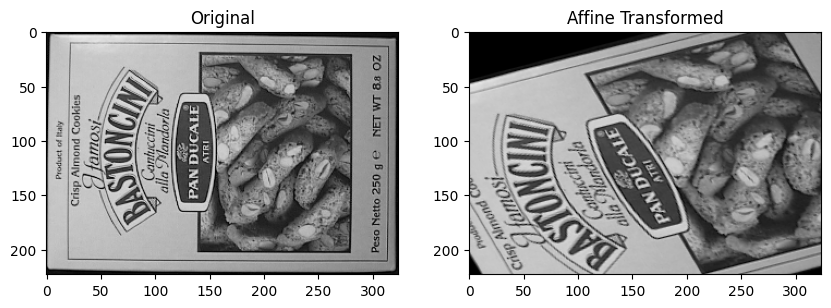

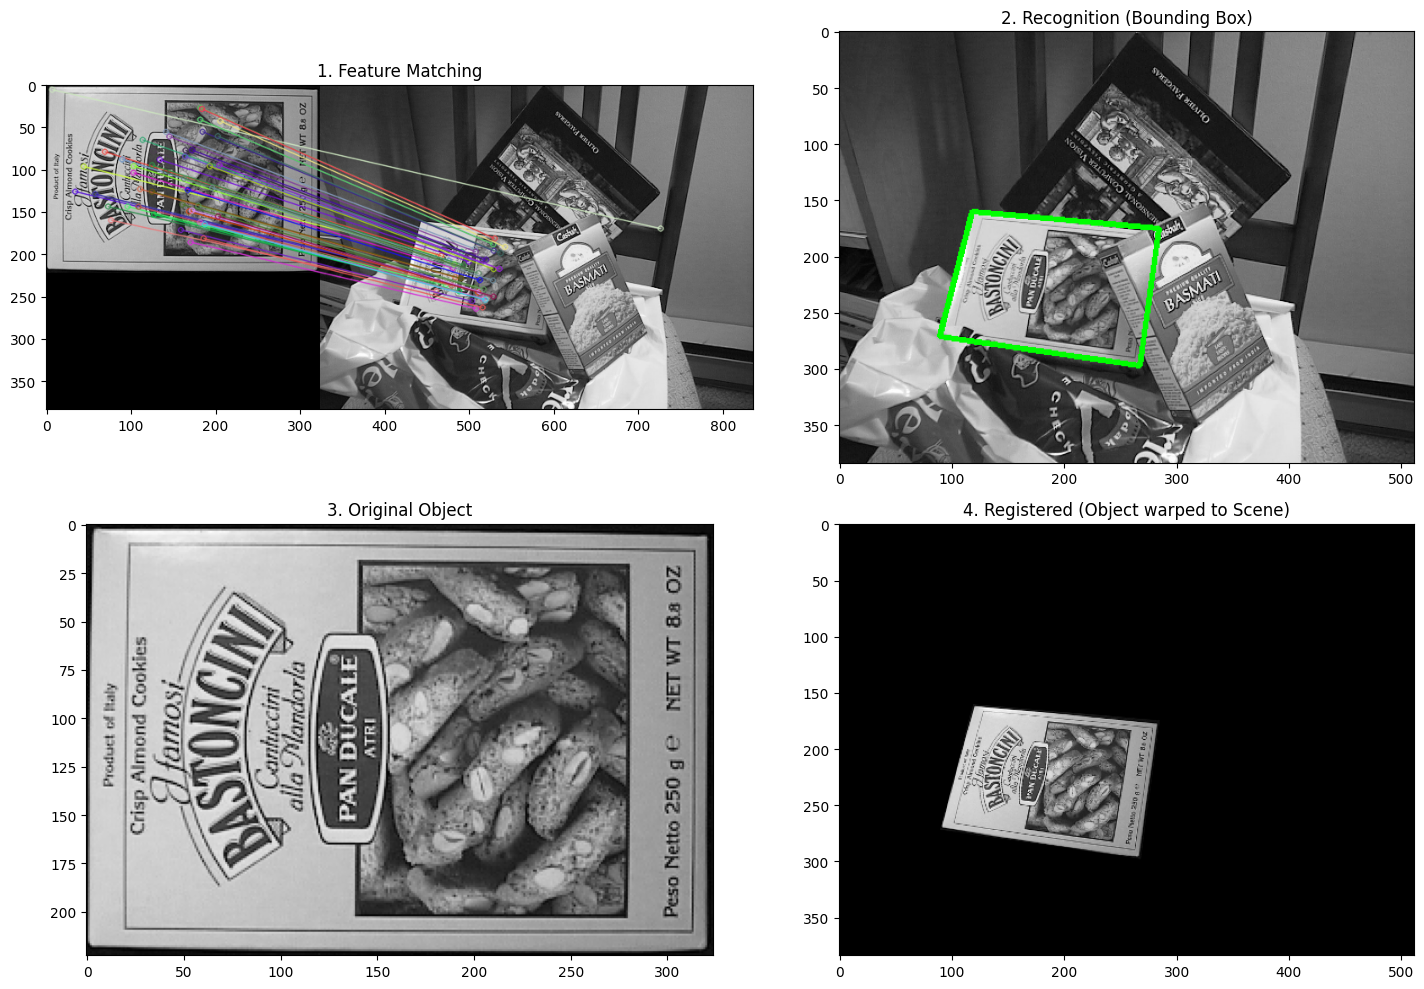

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

# --- 1. Helper to fetch images locally ---
def get_sample_images():
    base_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/"
    images = {
        'box.png': base_url + 'box.png',         # The object to find
        'box_in_scene.png': base_url + 'box_in_scene.png' # The scene
    }
    for name, url in images.items():
        if not os.path.exists(name):
            r = requests.get(url)
            with open(name, 'wb') as f:
                f.write(r.content)
    return 'box.png', 'box_in_scene.png'

# --- 2. Part 1: Affine Transformation ---
def demo_affine(image_path):
    img = cv2.imread(image_path)
    if img is None: return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rows, cols, _ = img.shape

    # Define 3 points in original and their new locations
    pts1 = np.float32([[50, 50], [200, 50], [50, 200]])
    pts2 = np.float32([[10, 100], [200, 50], [100, 250]])

    M = cv2.getAffineTransform(pts1, pts2)
    transformed_img = cv2.warpAffine(img, M, (cols, rows))

    plt.figure(figsize=(10, 4))
    plt.subplot(121), plt.imshow(img), plt.title('Original')
    plt.subplot(122), plt.imshow(transformed_img), plt.title('Affine Transformed')
    plt.show()

# --- 3. Part 2: Recognition & Registration ---
def recognize_and_register(object_path, scene_path):
    # Load images
    img_obj = cv2.imread(object_path, cv2.IMREAD_GRAYSCALE)
    img_scene = cv2.imread(scene_path, cv2.IMREAD_GRAYSCALE)
    img_scene_color = cv2.imread(scene_path)
    img_scene_color = cv2.cvtColor(img_scene_color, cv2.COLOR_BGR2RGB)

    # A. Feature Detection (using SIFT for better registration accuracy)
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img_obj, None)
    kp2, des2 = sift.detectAndCompute(img_scene, None)

    # B. Feature Matching (FLANN)
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des1, des2, k=2)

    # Lowe's ratio test
    good_matches = [m for m, n in matches if m.distance < 0.7 * n.distance]

    if len(good_matches) > 10:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        # C. Find Homography (The heart of Registration)
        H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

        # --- Task: Object Recognition (Bounding Box) ---
        h, w = img_obj.shape
        pts = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)
        dst = cv2.perspectiveTransform(pts, H)
        scene_boxed = cv2.polylines(img_scene_color.copy(), [np.int32(dst)], True, (0, 255, 0), 3)

        # --- Task: Image Registration (Warping) ---
        # We warp the object to fit into the scene's perspective
        registered_img = cv2.warpPerspective(img_obj, H, (img_scene.shape[1], img_scene.shape[0]))

        # --- Visualization ---
        plt.figure(figsize=(15, 10))
        plt.subplot(221), plt.imshow(cv2.drawMatches(img_obj, kp1, img_scene_color, kp2, good_matches[:50], None, flags=2)), plt.title('1. Feature Matching')
        plt.subplot(222), plt.imshow(scene_boxed), plt.title('2. Recognition (Bounding Box)')
        plt.subplot(223), plt.imshow(img_obj, cmap='gray'), plt.title('3. Original Object')
        plt.subplot(224), plt.imshow(registered_img, cmap='gray'), plt.title('4. Registered (Object warped to Scene)')
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough matches found.")

# --- Execute ---
obj_file, scene_file = get_sample_images()
demo_affine(obj_file)
recognize_and_register(obj_file, scene_file)